Setup + Chargement des splits

In [ ]:
# Monte Drive — à exécuter en premier dans chaque notebook
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/FakeNewsProject'

os.makedirs(f'{BASE}/data/raw',       exist_ok=True)
os.makedirs(f'{BASE}/data/processed', exist_ok=True)
os.makedirs(f'{BASE}/models/bert_final', exist_ok=True)
os.makedirs(f'{BASE}/figures',        exist_ok=True)
os.makedirs(f'{BASE}/preds',          exist_ok=True)

print(f"✓ Drive monté — BASE = {BASE}")

Mounted at /content/drive
✓ Drive monté — BASE = /content/drive/MyDrive/FakeNewsProject


In [ ]:
!pip install mlflow
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import mlflow
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/FakeNewsProject'
train = pd.read_csv(f'{BASE}/data/processed/train.csv')
val   = pd.read_csv(f'{BASE}/data/processed/val.csv')
test  = pd.read_csv(f'{BASE}/data/processed/test.csv')

X_train, y_train = train['clean_text'].fillna(''), train['label']
X_val,   y_val   = val['clean_text'].fillna(''),   val['label']
X_test,  y_test  = test['clean_text'].fillna(''),  test['label']

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

TF-IDF + Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                                  roc_auc_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# TF-IDF avec bigrammes
tfidf = TfidfVectorizer(max_features=100000, ngram_range=(1,2),
                        sublinear_tf=True, min_df=2)
X_tr = tfidf.fit_transform(X_train)
X_v  = tfidf.transform(X_val)
X_te = tfidf.transform(X_test)

# Modèle 1 : Logistic Regression
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_tr, y_train)
lr_pred  = lr.predict(X_te)
lr_proba = lr.predict_proba(X_te)[:,1]


# Modèle 2 : LinearSVC (souvent meilleur sur texte)
svc = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svc.fit(X_tr, y_train)
svc_pred = svc.predict(X_te)

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_pred, target_names=['FAKE','REAL']))
print(f"AUC-ROC : {roc_auc_score(y_test, lr_proba):.4f}")

print("\n=== LINEAR SVC ===")
print(classification_report(y_test, svc_pred, target_names=['FAKE','REAL']))



=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.98      4696
        REAL       0.97      0.99      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980

AUC-ROC : 0.9982

=== LINEAR SVC ===
              precision    recall  f1-score   support

        FAKE       1.00      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
import os
import numpy as np

os.makedirs(f'{BASE}/preds', exist_ok=True)

np.save(f'{BASE}/preds/lr_probs.npy', lr_proba)
np.save(f'{BASE}/data/y_test.npy', y_test)

Matrice de confusion + courbe ROC

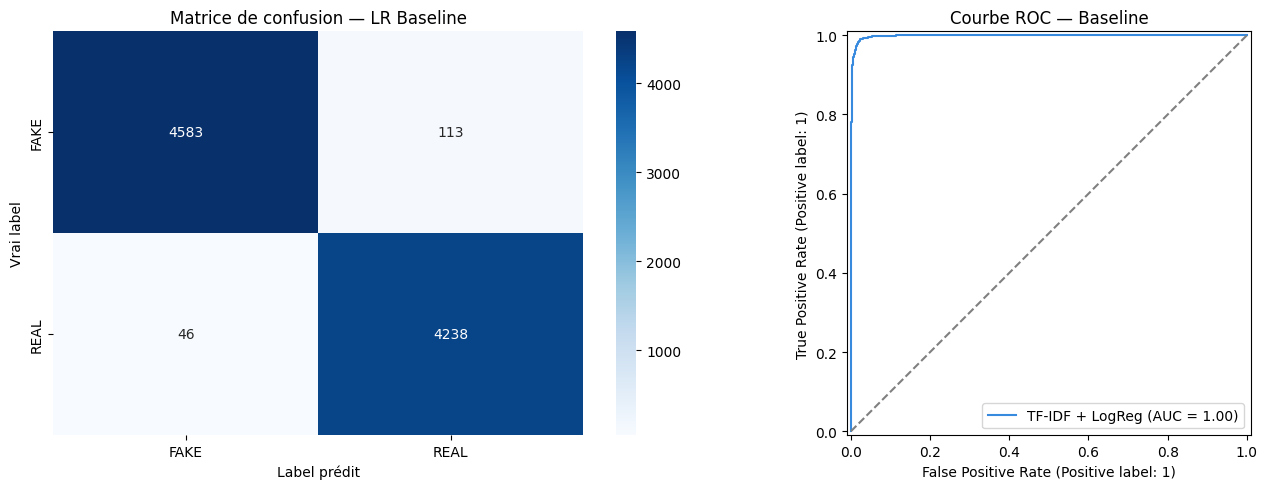

In [ ]:
from sklearn.metrics import RocCurveDisplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'],
            cmap='Blues')
axes[0].set_title('Matrice de confusion — LR Baseline')
axes[0].set_ylabel('Vrai label')
axes[0].set_xlabel('Label prédit')

# Courbe ROC
RocCurveDisplay.from_predictions(y_test, lr_proba, ax=axes[1],
                                  name='TF-IDF + LogReg', color='#378ADD')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title('Courbe ROC — Baseline')

plt.tight_layout()
plt.savefig(f'{BASE}/figures/baseline_metrics.png', dpi=150)
plt.show()

SHAP - Quel mot influencent le modèle

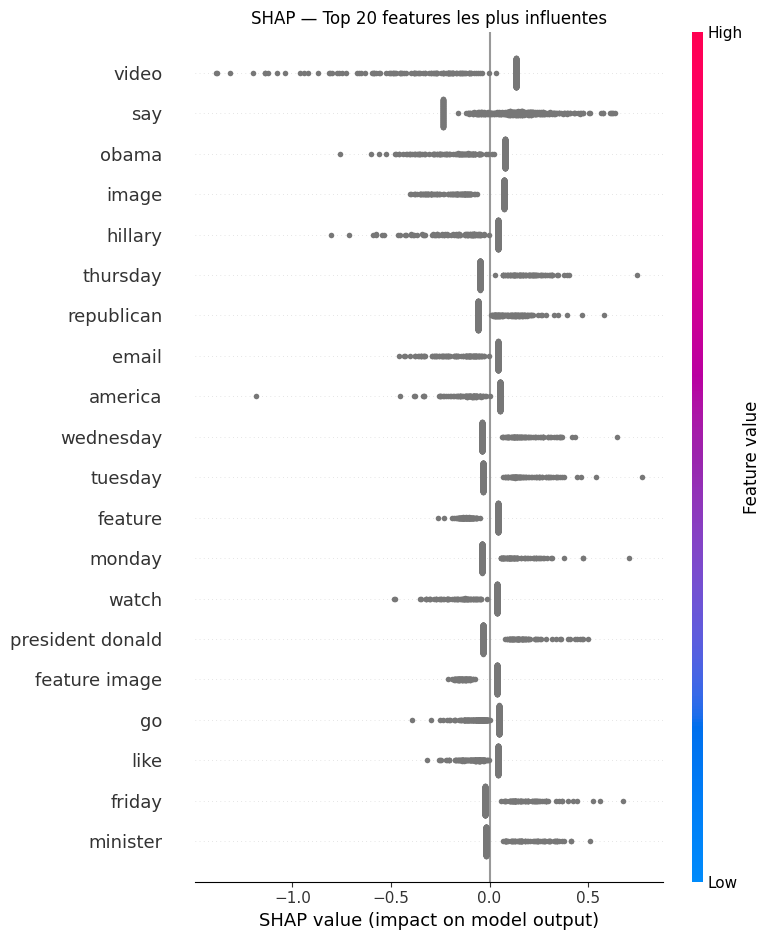


Top 15 mots les plus discriminants :
  video                           SHAP=0.1991
  say                             SHAP=0.1814
  obama                           SHAP=0.1093
  image                           SHAP=0.1031
  hillary                         SHAP=0.0750
  thursday                        SHAP=0.0743
  republican                      SHAP=0.0731
  email                           SHAP=0.0704
  america                         SHAP=0.0667
  wednesday                       SHAP=0.0627
  tuesday                         SHAP=0.0604
  feature                         SHAP=0.0583
  monday                          SHAP=0.0581
  watch                           SHAP=0.0576
  president donald                SHAP=0.0571


In [ ]:
!pip install -q shap
import shap

# SHAP sur un sous-ensemble (RAM)
X_shap = tfidf.transform(X_test[:500])
explainer = shap.LinearExplainer(lr, X_tr, feature_perturbation="interventional")
shap_vals = explainer.shap_values(X_shap)

feature_names = tfidf.get_feature_names_out()

# Top 20 mots les plus influents globalement
shap.summary_plot(shap_vals, X_shap, feature_names=feature_names,
                  max_display=20, show=False)
plt.title('SHAP — Top 20 features les plus influentes')
plt.tight_layout()
plt.savefig(f'{BASE}/figures/shap_baseline.png', dpi=150)
plt.show()

# Top mots FAKE vs REAL
mean_shap = np.abs(shap_vals).mean(axis=0)
top_idx   = np.argsort(mean_shap)[-15:]
print("\nTop 15 mots les plus discriminants :")
for i in top_idx[::-1]:
    print(f"  {feature_names[i]:30s}  SHAP={mean_shap[i]:.4f}")

MLflow

In [ ]:
mlflow.set_tracking_uri(f'{BASE}/mlruns')
mlflow.set_experiment("fake-news-detection")

with mlflow.start_run(run_name="TF-IDF_LogReg_baseline"):
    mlflow.log_params({"model":"LogisticRegression",
                       "vectorizer":"TF-IDF",
                       "max_features":100000,
                       "ngram_range":"(1,2)"})
    mlflow.log_metrics({
        "f1_fake"  : f1_score(y_test, lr_pred, pos_label=0),
        "f1_real"  : f1_score(y_test, lr_pred, pos_label=1),
        "f1_macro" : f1_score(y_test, lr_pred, average='macro'),
        "auc_roc"  : roc_auc_score(y_test, lr_proba)
    })
    mlflow.log_artifact(f'{BASE}/figures/baseline_metrics.png')
    mlflow.sklearn.log_model(lr, "logreg_model")

print("✓ Baseline loggée dans MLflow")
print(f"F1 macro baseline : {f1_score(y_test, lr_pred, average='macro'):.4f}")
print("→ C'est le score à battre avec LSTM puis BERT")

2026/04/08 10:29:14 INFO mlflow.tracking.fluent: Experiment with name 'fake-news-detection' does not exist. Creating a new experiment.
2026/04/08 10:29:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/08 10:29:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Baseline loggée dans MLflow
F1 macro baseline : 0.9823
→ C'est le score à battre avec LSTM puis BERT


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/FakeNewsProject'

Mounted at /content/drive
